# Importing Libraries

In [1]:
import sys
from pathlib import Path
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns

# Loading Dataset

In [3]:
sys.path.append(str(Path().resolve().parents[1]))
from dm_classif.config import RAW_DATA_DIR

import pandas as pd

# Load the CSV
file_path = RAW_DATA_DIR / "raw_diabetes_data.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


# Basic Inspection

In [4]:
df.shape

(70692, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [6]:
#Statistical summary of the DataFrame
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


In [6]:
#Check for missing values in each column
df.isnull().sum() 

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

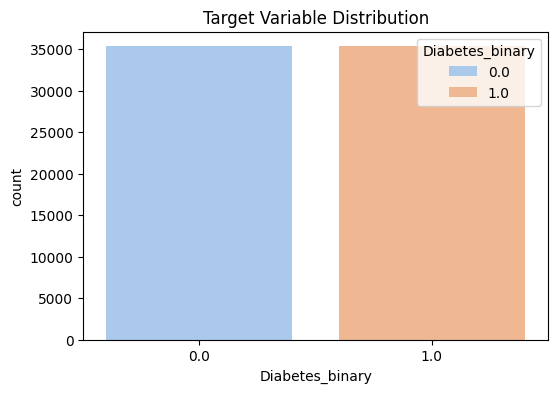

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Diabetes_binary', hue='Diabetes_binary', palette="pastel")
plt.title("Target Variable Distribution")
plt.show()

# Duplicate Inspection

In [10]:
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")

# view few duplicate rows
if total_duplicates > 0:
    duplicate_rows = df[df.duplicated()]
    display(duplicate_rows.head())

Total duplicate rows: 1635


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
602,0.0,0.0,0.0,1.0,22.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
689,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
891,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
1092,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
1326,0.0,1.0,0.0,1.0,29.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,10.0,5.0,6.0


# Outlier Inspection

In [11]:
# Z-score method
bmi_col = 'BMI'
z_scores = np.abs(zscore(df[bmi_col]))
outliers_z = z_scores > 3
print(f"Outliers detected (Z-score > 3): {outliers_z.sum()}")

# IQR method
Q1 = df[bmi_col].quantile(0.25)
Q3 = df[bmi_col].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = (df[bmi_col] < (Q1 - 1.5 * IQR)) | (df[bmi_col] > (Q3 + 1.5 * IQR))
print(f"Outliers detected (IQR method): {outliers_iqr.sum()}")

Outliers detected (Z-score > 3): 801
Outliers detected (IQR method): 2181


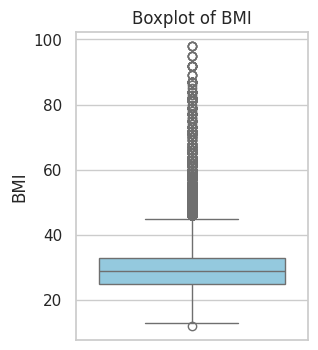

In [12]:
sns.set(style="whitegrid")
plt.figure(figsize=(3, 4))
sns.boxplot(y=df['BMI'], color="skyblue")
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.xlabel('')
plt.show()

# Observations

### Dataset Encoding Given

|Column Name|Encoding|
|-----------|--------|
|1. **Diabetes_binary**| 0 = no diabetes, 1 = prediabetes/diabetes|
|2. **HighBP**| 0 = no high BP, 1 = high BP|
|3. **HighChol**| 0 = no high cholesterol, 1 = high cholesterol|
|4. **CholCheck**| 0 = no cholesterol check in 5 years, 1 = yes cholesterol check in 5 years|
|5. **BMI**| Body Mass Index|
|6. **Smoker**| Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no, 1 = yes|
|7. **Stroke**| (Ever told) you had a stroke. 0 = no, 1 = yes|
|8. **HeartDiseaseorAttack**| coronary heart disease (CHD) or myocardial infarction (MI) 0 = no, 1 = yes|
|9. **PhysActivity**| physical activity in past 30 days - not including job 0 = no, 1 = yes|
|10. **Fruits**| Consume Fruit 1 or more times per day 0 = no, 1 = yes|
|11. **Veggies**| Consume Vegetables 1 or more times per day 0 = no, 1 = yes|
|12. **HvyAlcoholConsump**| (adult men >=14 drinks per week and adult women>=7 drinks per week) 0 = no, 1 = yes|
|13. **AnyHealthcare**| Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc. 0 = no, 1 = yes|
|14. **NoDocbcCost**| Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no, 1 = yes|
|15. **GenHlth**| Would you say that in general your health is: scale 1-5, 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor|
|16. **MentHlth**| days of poor mental health scale 1-30 days|
|17. **PhysHlth**| physical illness or injury days in past 30 days scale 1-30|
|18. **DiffWalk**| Do you have serious difficulty walking or climbing stairs? 0 = no, 1 = yes|
|19. **Sex**| 0 = female, 1 = male|
|20. **Age**| 13-level age category (_AGEG5YR see codebook) 1 = 18-24, 9 = 60-64, 13 = 80 or older|
|21. **Education**| Education level (EDUCA see codebook) scale 1-6, 1 = Never attended school or only kindergarten, 2 = elementary etc.|
|22. **Income**| Income scale (INCOME2 see codebook) scale 1-8, 1 = < $10,000, 5 = < $35,000, 8 = $75,000 or more|

### Findings and speculations

1. The entire dataset has **22** features and **70,692** data points.

2. 'Diabetes_binary' is the target Varaible which has **2 classes**, 0=No diabetes and 
1=diabetic/prediabetic, also both the classes are perfectly balanced.

3. There are **1635** duplicate values.

4. The dataset has **no Null/missing values**.

5. The *'BMI'* column contains outliers, but since our goal is to identify individuals with diabetes, we will retain these outliers as they may carry important information relevant to the prediction.
